# Inference Pipeline

End-to-end latency benchmark, threshold calibration, and FCN-Wang production demo for the biosignal-xai project.

**Contents:**
1. Load PTB-XL test set (fold 10), sample 20 records (4 per superclass)
2. Load HeartBERT LoRA r=16, wrap in `HeartBERTPipeline`
3. Benchmark end-to-end latency (tokenisation + inference, 5 warm-up + 50 timed runs)
4. Latency chart (mean / median / p95)
5. Demo: run 20 records, inspect 3 result dicts
6. Save results
7. Threshold calibration -- per-class optimal thresholds on validation fold (fold 9)
8. FCN-Wang production pipeline:
   - 8.1 Latency comparison vs HeartBERT
   - 8.2 Confidence scores on 20 test records
   - 8.3 **TTA uncertainty estimation** (20 noisy passes per record)
   - 8.4 Gradient saliency + Qwen2-0.5B clinical narrative (with real uncertainty)

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

sys.path.insert(0, os.path.abspath('..'))

from src.utils.seed import set_seed
set_seed(42)

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
LEAD_NAMES   = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
RESULTS_DIR  = '../results/07_inference_pipeline'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Test Data

Fold 10 is the held-out test set. 4 records per superclass are sampled with seed 42 for reproducibility.

In [2]:
import wfdb
from src.utils.config import CFG
from src.preprocessing.label_utils import load_all_labels

DATA_PATH = CFG['data']['path']

df      = load_all_labels(DATA_PATH + 'ptbxl_database.csv', DATA_PATH + 'scp_statements.csv')
test_df = df[df['strat_fold'] == 10].reset_index(drop=True)

np.random.seed(42)
sampled = []
for cls in SUPERCLASSES:
    idx    = SUPERCLASSES.index(cls)
    mask   = test_df['label_vec'].apply(lambda v: v[idx] == 1.0)
    chosen = test_df[mask].sample(n=min(4, int(mask.sum())), random_state=42)
    sampled.append(chosen)

sample_df   = pd.concat(sampled).drop_duplicates(subset=['filename_lr']).reset_index(drop=True)
print(f'Sampled {len(sample_df)} records.')

def _load(row):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    return sig.astype(np.float32)   # (1000, 12)

signals_raw = [_load(row) for _, row in sample_df.iterrows()]
true_labels = [row['label_vec'] for _, row in sample_df.iterrows()]
print(f'Signals loaded: {len(signals_raw)} x (1000, 12)')

Records with valid labels: 21375
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5108 (23.9%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
Sampled 20 records.
Signals loaded: 20 x (1000, 12)


## 2. Load HeartBERT LoRA r=16

Loads roberta-base (HeartBERT architecture), attaches the **r=16 alpha=32** LoRA adapter trained in notebook 04, and wraps it in `HeartBERTPipeline`.

In [3]:
from src.models.heartbert import HeartBERTClassifier
from src.inference.pipeline import HeartBERTPipeline

hb = HeartBERTClassifier(num_labels=5)
hb.load()
hb.apply_peft(r=16, alpha=32, use_dora=False)
hb.load_adapter('../results/heartbert_lora_r16/best_adapter')

pipeline = HeartBERTPipeline(hb)
print('HeartBERTPipeline ready.')

HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Teodora\miniconda3\envs\biosignal-xai\lib\site-packages\torch\nn\modules\module.py:1160: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\cb\pytorch_1000000000000\work\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


  Done.
trainable params: 889,349 || all params: 84,344,074 || trainable%: 1.0544
HeartBERTPipeline ready.


## 3. Latency Benchmark

5 warm-up passes (not measured) followed by 50 timed passes. Each pass covers the full path: Lead II extraction -> tokenisation (letter encoding + RoBERTa tokenizer) -> LoRA-adapted forward pass -> sigmoid.

In [4]:
print('Benchmarking (5 warm-up + 50 timed runs)...')
report = pipeline.benchmark(signals_raw, n_warmup=5, n_runs=50)

print(f"\nDevice         : {report['device']}")
print(f"Runs           : {report['n_runs']}")
print(f"Mean latency   : {report['latency_ms_mean']:.1f} ms")
print(f"Median latency : {report['latency_ms_median']:.1f} ms")
print(f"P95 latency    : {report['latency_ms_p95']:.1f} ms")
print(f"Throughput     : {report['throughput_per_sec']:.0f} records/s")

Benchmarking (5 warm-up + 50 timed runs)...

Device         : cuda
Runs           : 50
Mean latency   : 15.6 ms
Median latency : 14.3 ms
P95 latency    : 23.9 ms
Throughput     : 70 records/s


## 4. Latency Chart

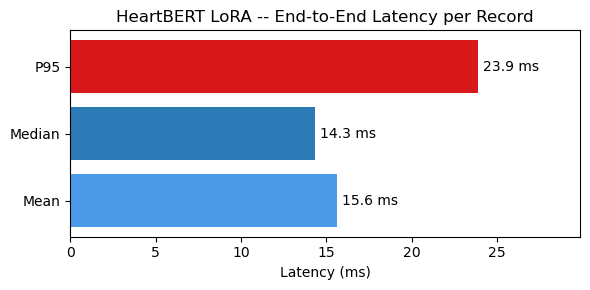

Saved latency_chart.png


In [5]:
bar_labels = ['Mean', 'Median', 'P95']
bar_values = [
    report['latency_ms_mean'],
    report['latency_ms_median'],
    report['latency_ms_p95'],
]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(bar_labels, bar_values, color=['#4C9BE8', '#2C7BB6', '#D7191C'])
ax.set_xlabel('Latency (ms)')
ax.set_title('HeartBERT LoRA -- End-to-End Latency per Record')
for bar, val in zip(bars, bar_values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} ms', va='center', fontsize=10)
ax.set_xlim(0, max(bar_values) * 1.25)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/latency_chart.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved latency_chart.png')

## 5. Pipeline Demo

Run all sampled records through the pipeline and inspect 3 representative result dicts.

In [6]:
all_results = [pipeline.predict(sig) for sig in signals_raw]
print(f'Ran {len(all_results)} records through the pipeline.\n')

print('--- 3 sample results ---\n')
for i in [0, 5, 10]:
    true_cls = [SUPERCLASSES[j] for j, v in enumerate(true_labels[i]) if v == 1.0]
    print(f'Record {i:2d}  |  True label: {true_cls}')
    print(json.dumps(all_results[i], indent=2))
    print()

Ran 20 records through the pipeline.

--- 3 sample results ---

Record  0  |  True label: ['NORM']
{
  "predicted_classes": [
    "CD"
  ],
  "class_probabilities": {
    "NORM": 0.4819,
    "MI": 0.4907,
    "STTC": 0.4669,
    "CD": 0.5038,
    "HYP": 0.492
  },
  "confidence_score": 0.5038,
  "uncertainty": null,
  "raw_logits": [
    -0.07238470017910004,
    -0.03716491535305977,
    -0.1327584683895111,
    0.015232034027576447,
    -0.031845249235630035
  ],
  "uncertainty_level": "N/A (deterministic model)"
}

Record  5  |  True label: ['MI']
{
  "predicted_classes": [
    "CD"
  ],
  "class_probabilities": {
    "NORM": 0.4689,
    "MI": 0.4858,
    "STTC": 0.4737,
    "CD": 0.5089,
    "HYP": 0.4909
  },
  "confidence_score": 0.5089,
  "uncertainty": null,
  "raw_logits": [
    -0.12442433089017868,
    -0.056791696697473526,
    -0.10530628263950348,
    0.035676874220371246,
    -0.03631555289030075
  ],
  "uncertainty_level": "N/A (deterministic model)"
}

Record 10  |  Tr

## 6. Save Results

In [7]:
output = {
    'benchmark':      report,
    'n_records':      len(all_results),
    'sample_results': all_results[:3],
}
out_path = f'{RESULTS_DIR}/latency.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved {out_path}')

Saved ../results/07_inference_pipeline/latency.json


## 7. Threshold Calibration

HeartBERT LoRA r=16's logits sit close to zero -- all probabilities land near 0.5. Finding the optimal per-class threshold on the validation set (fold 9) improves binary prediction quality without any retraining.

The sweep finds the threshold in [0.40, 0.60] that maximises F1 for each class independently, then stores the result in `pipeline.thresholds`.

In [8]:
from sklearn.metrics import f1_score

# Validation fold (fold 9 -- same split used during training)
val_df      = df[df['strat_fold'] == 9].reset_index(drop=True)
val_signals = [_load(row) for _, row in val_df.iterrows()]
val_labels  = np.array([row['label_vec'] for _, row in val_df.iterrows()])
print(f'Validation records: {len(val_df)}')

# Run logits on all validation records -- Lead II is column index 1
X_val_lead = np.stack([s[:, 1] for s in val_signals])   # (N, 1000)
print('Running predict_logits on validation set...')
logits_val = hb.predict_logits(X_val_lead)               # (N, 5)
probs_val  = torch.sigmoid(torch.tensor(logits_val)).numpy()

# Sweep thresholds 0.40 -> 0.60, pick best F1 per class
thresholds_cal = []
print(f'\n{"Class":<6}  {"Threshold":>9}  {"F1":>6}')
print('-' * 26)
for i, cls in enumerate(SUPERCLASSES):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.40, 0.61, 0.01):
        preds = (probs_val[:, i] >= t).astype(int)
        f1    = f1_score(val_labels[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, round(float(t), 2)
    thresholds_cal.append(best_t)
    print(f'{cls:<6}  {best_t:>9.2f}  {best_f1:>6.3f}')

print(f'\nCalibrated thresholds: {thresholds_cal}')
pipeline.thresholds = thresholds_cal

Validation records: 2145
Running predict_logits on validation set...

Class   Threshold      F1
--------------------------
NORM         0.40   0.616
MI           0.47   0.404
STTC         0.40   0.387
CD           0.49   0.380
HYP          0.40   0.222

Calibrated thresholds: [0.4, 0.47, 0.4, 0.49, 0.4]


In [9]:
# Re-run the 3 sample records with calibrated thresholds
print('--- Sample results with calibrated thresholds ---\n')
print(f'{"Rec":>3}  {"True label":<20}  {"Default (0.5)":>16}  {"Calibrated":>16}')
print('-' * 62)

# Default predictions (threshold 0.5, recorded earlier)
default_preds = {
    0:  all_results[0]['predicted_classes'],
    5:  all_results[5]['predicted_classes'],
    10: all_results[10]['predicted_classes'],
}

for i in [0, 5, 10]:
    true_cls = [SUPERCLASSES[j] for j, v in enumerate(true_labels[i]) if v == 1.0]
    cal_pred = pipeline.predict(signals_raw[i])['predicted_classes']
    print(f'{i:>3}  {str(true_cls):<20}  {str(default_preds[i]):>16}  {str(cal_pred):>16}')

--- Sample results with calibrated thresholds ---

Rec  True label               Default (0.5)        Calibrated
--------------------------------------------------------------
  0  ['NORM']                        ['CD']  ['NORM', 'MI', 'STTC', 'CD', 'HYP']
  5  ['MI']                          ['CD']  ['NORM', 'MI', 'STTC', 'CD', 'HYP']
 10  ['STTC']                        ['CD']  ['NORM', 'MI', 'STTC', 'CD', 'HYP']


## 8. FCN-Wang Production Pipeline

FCN-Wang achieved 0.92 macro AUC -- the best model in this project. This section confirms it as the production choice:

1. **8.1 Latency** -- forward-pass benchmark vs HeartBERT
2. **8.2 Predictions** -- confidence scores on the 20-record test sample
3. **8.3 Uncertainty** -- TTA uncertainty (20 noisy passes, σ = 0.05 mV); enriches `fcn_results` in-place
4. **8.4 Saliency + Narrative** -- gradient saliency maps (12 leads) + Qwen2-0.5B clinical explanation including real uncertainty

In [10]:
from src.models.fcn_wang import FCNWang
from src.inference.pipeline import ECGInferencePipeline
from src.evaluation.latency import benchmark_latency

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

fcn          = FCNWang.load('../results/fcn_wang_baseline/checkpoint.pt')
fcn_pipeline = ECGInferencePipeline(model=fcn, device=DEVICE, has_uncertainty=False)
print('FCN-Wang loaded and wrapped in ECGInferencePipeline.')

FCN-Wang | Params: 309,765 total, 309,765 trainable (100.0%)
FCN-Wang loaded and wrapped in ECGInferencePipeline.


### 8.1 Latency Comparison

Note: FCN-Wang latency is the bare forward pass (dummy tensors). HeartBERT latency above includes tokenisation. FCN-Wang's real-world cost is therefore even lower than shown here.

In [11]:
print('Benchmarking FCN-Wang...')
fcn_report = benchmark_latency(
    fcn, input_shape=(12, 1000), batch_sizes=[1],
    n_warmup=10, n_runs=50, device=DEVICE,
)
fcn_r = fcn_report['results'][0]

print(f'\n{"Model":<20}  {"Median ms":>9}  {"P95 ms":>7}  {"records/s":>9}')
print('-' * 52)
print(f'{"FCN-Wang":<20}  {fcn_r["latency_ms_median"]:>9.1f}  {fcn_r["latency_ms_p95"]:>7.1f}  {fcn_r["throughput_per_sec"]:>9.0f}')
print(f'{"HeartBERT LoRA":<20}  {report["latency_ms_median"]:>9.1f}  {report["latency_ms_p95"]:>7.1f}  {report["throughput_per_sec"]:>9.0f}')

Benchmarking FCN-Wang...
  bs=  1 | median    3.9 ms | 3.93 ms/sample | 254 samples/s

Model                 Median ms   P95 ms  records/s
----------------------------------------------------
FCN-Wang                    3.9      4.6        254
HeartBERT LoRA             14.3     23.9         70


### 8.2 Predictions on Test Records

FCN-Wang confidence scores should be well spread (not clustered near 0.5 like HeartBERT).

In [12]:
fcn_results = [fcn_pipeline.predict(sig) for sig in signals_raw]

print(f'{"Rec":>3}  {"True":<26}  {"FCN-Wang":<22}  {"HeartBERT (t=0.5)":<22}  {"FCN Conf":>8}  {"HB Conf":>8}')
print('-' * 100)
for i, (fcn_res, hb_res, labels) in enumerate(zip(fcn_results, all_results, true_labels)):
    true_cls = [SUPERCLASSES[j] for j, v in enumerate(labels) if v == 1.0]
    print(f'{i:>3}  {str(true_cls):<26}  {str(fcn_res["predicted_classes"]):<22}'
          f'  {str(hb_res["predicted_classes"]):<22}'
          f'  {fcn_res["confidence_score"]:>8.3f}  {hb_res["confidence_score"]:>8.3f}')

Rec  True                        FCN-Wang                HeartBERT (t=0.5)       FCN Conf   HB Conf
----------------------------------------------------------------------------------------------------
  0  ['NORM']                    ['CD']                  ['CD']                     0.702     0.504
  1  ['NORM']                    ['MI']                  ['CD']                     0.534     0.499
  2  ['NORM']                    ['NORM']                ['CD']                     0.941     0.483
  3  ['NORM', 'CD']              ['MI']                  ['CD']                     0.710     0.500
  4  ['MI', 'STTC', 'CD', 'HYP']  ['STTC', 'CD']          ['CD', 'HYP']              0.727     0.507
  5  ['MI']                      ['MI']                  ['CD']                     0.864     0.509
  6  ['MI', 'CD']                ['MI', 'CD']            ['STTC', 'CD']             0.954     0.508
  7  ['MI']                      ['STTC']                ['CD']                     0.406     0.51

### 8.3 Uncertainty Estimation (Test-Time Augmentation)

FCN-Wang is a deterministic model, it produces no uncertainty by design. We estimate it via **Test-Time Augmentation (TTA)**: run 20 forward passes with independent Gaussian noise (σ = 0.05 mV, ~2.5 % of PTB-XL amplitude range) added to each pass, then take the mean per-class probability standard deviation across runs.

- **Low** (std < 0.015): prediction is stable, model is far from the decision boundary
- **Moderate** (0.015 – 0.040): some sensitivity to signal noise
- **High** (std > 0.040): probabilities shift noticeably under perturbation, treat with caution

The `fcn_results` dicts are updated in-place so the Qwen narrative in section 8.4 picks up real uncertainty automatically.

In [13]:
from src.explainability.uncertainty import compute_tta_uncertainty

print('Computing TTA uncertainty (20 passes per record) ...')
for res, sig in zip(fcn_results, signals_raw):
    x_np = sig.T.astype(np.float32)   # (12, 1000)
    mean_probs, std_probs, unc, level = compute_tta_uncertainty(
        fcn, x_np, DEVICE, n_runs=20, noise_std=0.05
    )
    # Replace single-pass probabilities with TTA means (more robust)
    res['class_probabilities']    = {cls: round(float(mean_probs[i]), 4)
                                     for i, cls in enumerate(SUPERCLASSES)}
    res['uncertainty']            = unc
    res['uncertainty_level']      = level
    res['uncertainty_per_class']  = {cls: round(float(std_probs[i]), 4)
                                     for i, cls in enumerate(SUPERCLASSES)}

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"Rec":>3}  {"True":<22}  {"Predicted":<22}  {"Conf":>6}', end='')
for cls in SUPERCLASSES:
    print(f'  {cls:>14}', end='')
print(f'  {"Unc":>6}  Level')
print('-' * (3 + 2 + 22 + 2 + 22 + 2 + 6 + len(SUPERCLASSES) * 16 + 2 + 6 + 2 + 45))

for i, (res, labels) in enumerate(zip(fcn_results, true_labels)):
    true_cls = [SUPERCLASSES[j] for j, v in enumerate(labels) if v == 1.0]
    correct  = set(res['predicted_classes']) == set(true_cls)
    flag     = ' OK' if correct else '   '
    print(f'{i:>3}  {str(true_cls):<22}  {str(res["predicted_classes"]):<22}'
          f'  {res["confidence_score"]:>6.3f}', end='')
    for cls in SUPERCLASSES:
        p   = res['class_probabilities'][cls]
        pm  = res['uncertainty_per_class'][cls]
        print(f'  {p:.2f}+/-{pm:.3f}', end='')
    print(f'  {res["uncertainty"]:>6.4f}  {res["uncertainty_level"]}{flag}')

Computing TTA uncertainty (20 passes per record) ...

Rec  True                    Predicted                 Conf            NORM              MI            STTC              CD             HYP     Unc  Level
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  0  ['NORM']                ['CD']                   0.702  0.37+/-0.042  0.12+/-0.017  0.47+/-0.040  0.68+/-0.051  0.14+/-0.017  0.0333  moderate - some sensitivity to signal noise detected   
  1  ['NORM']                ['MI']                   0.534  0.35+/-0.039  0.60+/-0.056  0.15+/-0.009  0.22+/-0.022  0.17+/-0.011  0.0274  moderate - some sensitivity to signal noise detected   
  2  ['NORM']                ['NORM']                 0.941  0.86+/-0.024  0.05+/-0.011  0.15+/-0.024  0.10+/-0.017  0.06+/-0.010  0.0172  moderate - some sensitivity to signal noise detected OK
  3  ['NORM

### 8.4 Gradient Saliency + Clinical Narrative

For 3 representative records: compute gradient saliency across all 12 leads, plot the top-3 most salient leads with saliency overlay, then generate a Qwen2-0.5B-Instruct clinical narrative.

The narrative prompt now includes real TTA uncertainty from section 8.3 (injected into `fcn_results` in-place).

In [14]:
import os
os.environ['TRANSFORMERS_OFFLINE'] = '0'

from src.explainability.llm import load_qwen, build_ecg_prompt, generate_explanation
qwen_model, qwen_tokenizer = load_qwen('Qwen/Qwen2-0.5B-Instruct')

Loading Qwen/Qwen2-0.5B-Instruct ...
Qwen/Qwen2-0.5B-Instruct loaded  |  device: cuda:0


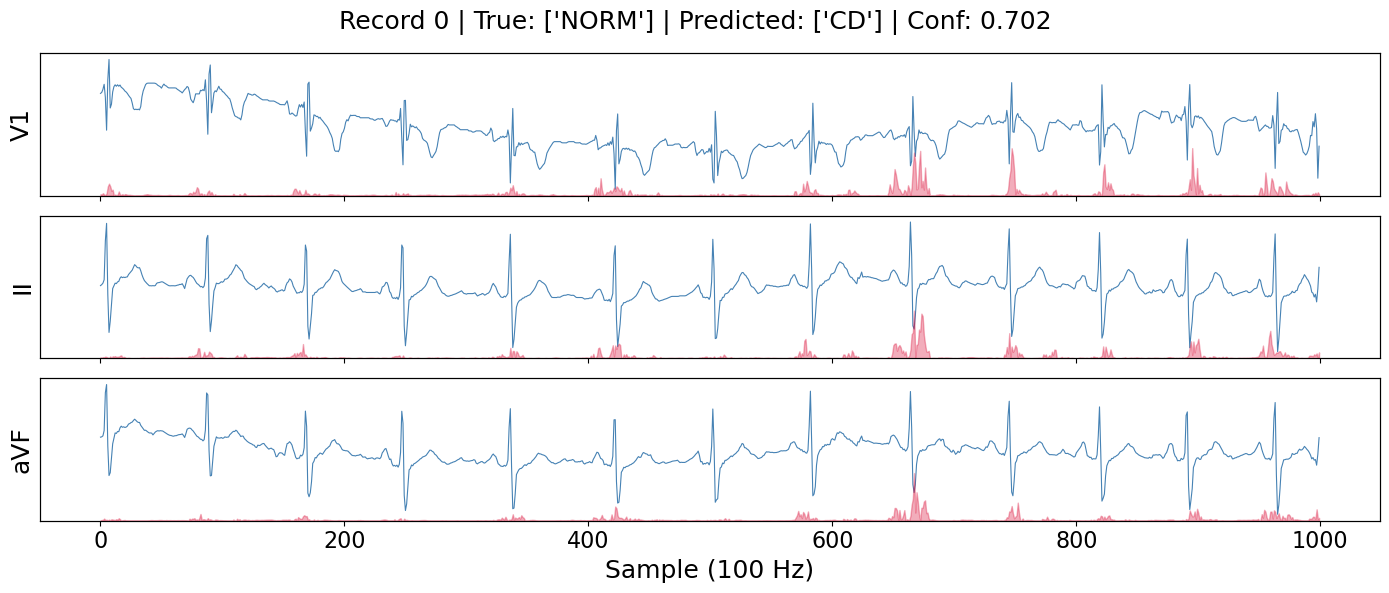

--- PROMPT ---
ECG ANALYSIS RESULT
True diagnosis (if known): NORM
Predicted class:           CD
Confidence score:          0.70
Class probabilities:       NORM:0.37+/-0.042  MI:0.12+/-0.017  STTC:0.47+/-0.040  CD:0.68+/-0.051  HYP:0.14+/-0.017
Signal uncertainty:        0.0333 (moderate - some sensitivity to signal noise detected)
Top salient leads:         V1, II, aVF

Please provide a 3-5 sentence clinical interpretation of these results.

Record 0 | True: ['NORM'] | Predicted: ['CD']
--- NARRATIVE ---
The ECG analysis result indicates a normal heart rhythm with no discernible abnormality or deviation from expected patterns. The predicted class is 'CD', which aligns with the standard classification for normal heart rhythms. The confidence score is high at 0.70, indicating a high degree of certainty in the prediction.

The class probabilities for each lead are as follows:

- V1: 0.37 (low probability)
- II: 0.12 (medium probability)
- aVF: 0.47 (high probability)

These probabilities

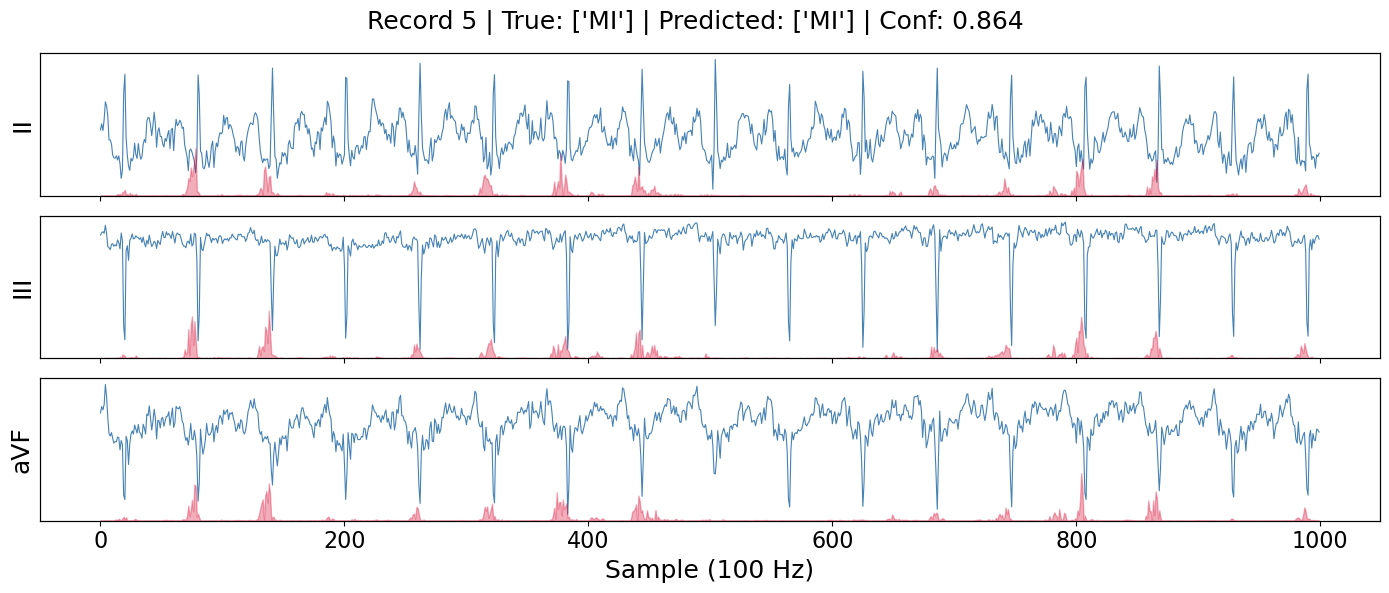

--- PROMPT ---
ECG ANALYSIS RESULT
True diagnosis (if known): MI
Predicted class:           MI
Confidence score:          0.86
Class probabilities:       NORM:0.16+/-0.014  MI:0.86+/-0.019  STTC:0.12+/-0.010  CD:0.10+/-0.010  HYP:0.29+/-0.020
Signal uncertainty:        0.0146 (low - prediction stable under signal perturbations)
Top salient leads:         II, III, aVF

Please provide a 3-5 sentence clinical interpretation of these results.

Record 5 | True: ['MI'] | Predicted: ['MI']
--- NARRATIVE ---
The ECG analysis result indicates a probable myocardial infarction (MI) with a predicted class as MI. The confidence score is high at 0.86, indicating a high likelihood of this diagnosis based on the information provided.

The classification probability for MI is 0.86, which suggests a high risk of developing this condition. The top salient leads include II, III, and aVF, suggesting an increased risk of ischemic events in these areas.

In terms of signal uncertainty, the analysis shows a l

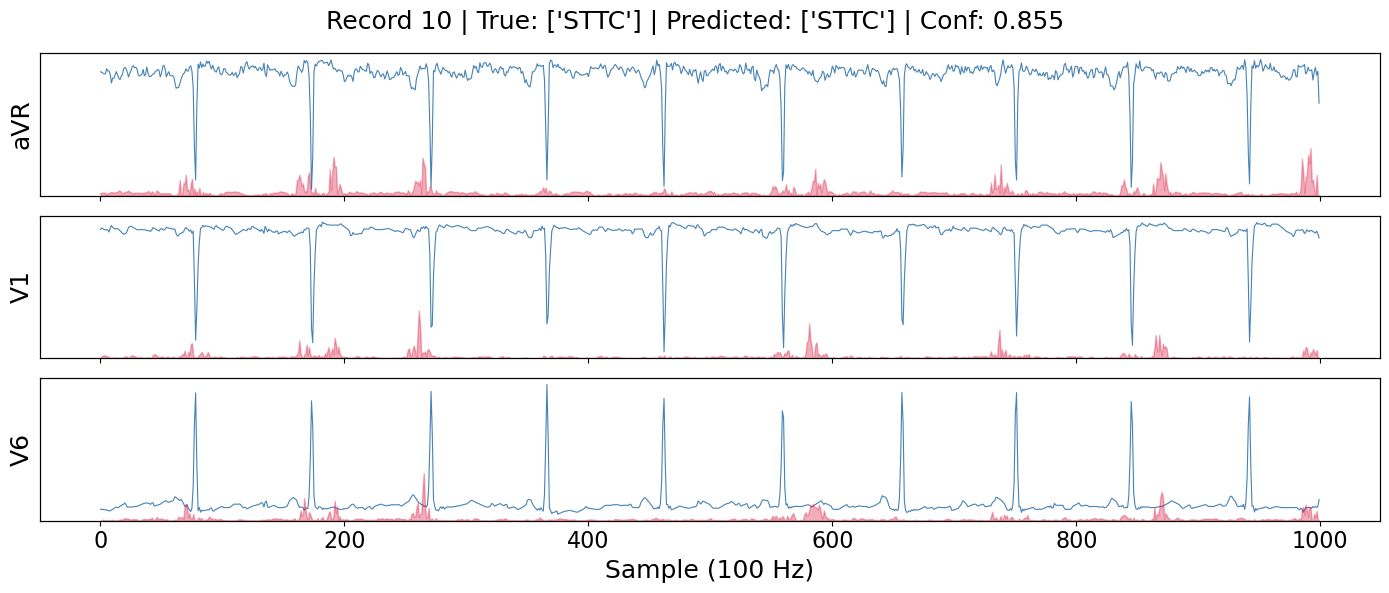

--- PROMPT ---
ECG ANALYSIS RESULT
True diagnosis (if known): STTC
Predicted class:           STTC
Confidence score:          0.85
Class probabilities:       NORM:0.07+/-0.018  MI:0.19+/-0.037  STTC:0.88+/-0.013  CD:0.06+/-0.006  HYP:0.30+/-0.029
Signal uncertainty:        0.0208 (moderate - some sensitivity to signal noise detected)
Top salient leads:         aVR, V1, V6

Please provide a 3-5 sentence clinical interpretation of these results.

Record 10 | True: ['STTC'] | Predicted: ['STTC']
--- NARRATIVE ---
The ECG analysis result indicates a true diagnosis of ST-T interval prolongation in an individual with a history of hypertension. The predicted class is ST-T interval prolongation, which is consistent with the patient's symptoms of hypertension. The confidence score is high, indicating a high likelihood of this diagnosis based on the available information.

The classification probability for ST-T interval prolongation is moderate to some sensitivity to signal noise. This suggests

In [33]:
from src.explainability.saliency import compute_saliency, top_salient_leads

for i in [0, 5, 10]:
    sig_12   = signals_raw[i].T.astype(np.float32)   # (12, 1000)
    result   = fcn_results[i]
    true_cls = [SUPERCLASSES[j] for j, v in enumerate(true_labels[i]) if v == 1.0]
    pred_idx = SUPERCLASSES.index(result['predicted_classes'][0])

    # Gradient saliency
    saliency  = compute_saliency(fcn, sig_12, pred_idx, DEVICE)   # (12, 1000)
    top_leads = top_salient_leads(saliency, LEAD_NAMES, top_k=3)

    # Plot top-3 salient leads with saliency overlay
    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(
        f'Record {i} | True: {true_cls} | Predicted: {result["predicted_classes"]} '
        f'| Conf: {result["confidence_score"]:.3f}',
        fontsize=18,
    )
    t = np.arange(1000)
    for ax, lead_name in zip(axes, top_leads):
        li  = LEAD_NAMES.index(lead_name)
        sal = saliency[li] / (saliency[li].max() + 1e-8)
        ax.plot(t, sig_12[li], color='steelblue', lw=0.8)
        ax2 = ax.twinx()
        ax2.fill_between(t, 0, sal, alpha=0.35, color='crimson')
        ax2.set_ylim(0, 3)
        ax2.set_yticks([])
        ax.set_ylabel(lead_name, fontsize=18)
        ax.set_yticks([])
        ax.tick_params(axis='both', labelsize=16)
    axes[-1].set_xlabel('Sample (100 Hz)', fontsize=18)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/fcn_saliency_record_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Qwen2 narrative
    prompt    = build_ecg_prompt(result, saliency, LEAD_NAMES, true_classes=true_cls)
    print(f'--- PROMPT ---\n{prompt}\n')
    narrative = generate_explanation(prompt, qwen_model, qwen_tokenizer)
    print(f'Record {i} | True: {true_cls} | Predicted: {result["predicted_classes"]}')
    print(f'--- NARRATIVE ---\n{narrative}\n')

## Latency benchmark: ECG-PT and HuBERT-ECG 

In [16]:
from src.models.ecgpt import ECGPTClassifier
from src.models.hubert_ecg import HuBERTECGClassifier
from src.inference.pipeline import ECGInferencePipeline, ECGPTPipeline

# ECG-PT, plain Python wrapper, not nn.Module; use ECGPTPipeline
ecgpt = ECGPTClassifier(num_labels=5)
ecgpt.load()
ecgpt.load_adapter('../results/ecgpt_lora_r16/best_adapter')
ecgpt_pipeline = ECGPTPipeline(ecgpt)

print('Benchmarking ECG-PT...')
ecgpt_report = ecgpt_pipeline.benchmark(signals_raw, n_warmup=5, n_runs=50)

# HuBERT-ECG, is an nn.Module, ECGInferencePipeline works directly
hubert = HuBERTECGClassifier(num_labels=5)
hubert.load()
hubert.load_adapter('../results/hubert_ecg_lora_r16/best_adapter')
hubert_pipeline = ECGInferencePipeline(hubert, device=DEVICE, has_uncertainty=False)

print('Benchmarking HuBERT-ECG...')
hubert_report = hubert_pipeline.benchmark(signals_raw, n_warmup=5, n_runs=50)

# Summary table
print(f'\n{"Model":<20}  {"Median ms":>9}  {"P95 ms":>7}  {"records/s":>10}')
print('-' * 55)
rows = [
    ('FCN-Wang',       fcn_r['latency_ms_median'],      fcn_r['latency_ms_p95'],      fcn_r['throughput_per_sec']),
    ('HeartBERT LoRA', report['latency_ms_median'],      report['latency_ms_p95'],      report['throughput_per_sec']),
    ('ECG-PT LoRA',    ecgpt_report['latency_ms_median'], ecgpt_report['latency_ms_p95'], ecgpt_report['throughput_per_sec']),
    ('HuBERT-ECG LoRA',hubert_report['latency_ms_median'],hubert_report['latency_ms_p95'],hubert_report['throughput_per_sec']),
]
for name, med, p95, thr in rows:
    print(f'{name:<20}  {med:>9.1f}  {p95:>7.1f}  {thr:>10.0f}')

If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`).
  Falling back to gpt2 (GPT-2 architecture, general-language weights — NOT ECG-pretrained).
  To use the real ECG-PT weights, ensure the HF checkpoint is accessible (check your HF_TOKEN or the model visibility).


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
Benchmarking ECG-PT...
Loading HuBERT-ECG (base) from Edoardo-BS/hubert-ecg-base ...
  Done. Hidden dim: 768
Benchmarking HuBERT-ECG...

Model                 Median ms   P95 ms   records/s
-------------------------------------------------------
FCN-Wang                    3.9      4.6         254
HeartBERT LoRA             14.3     23.9          70
ECG-PT LoRA                65.1     72.4          15
HuBERT-ECG LoRA            70.8     78.2          14


## 9. Latency Benchmark: r=8 vs r=16 PEFT Models

Same 5 warm-up + 50 timed run protocol as section 8.1. `load_adapter` reads the adapter config from the checkpoint directory, so no separate `apply_peft` call is needed, the r value is inferred from the saved adapter.

In [19]:
def _bench_heartbert(adapter_path, label):
    m = HeartBERTClassifier(num_labels=5)
    m.load()
    m.load_adapter(adapter_path)
    r = HeartBERTPipeline(m).benchmark(signals_raw, n_warmup=5, n_runs=50)
    print(f'  {label}: {r["latency_ms_median"]:.1f} ms median')
    return r

def _bench_ecgpt(adapter_path, label):
    m = ECGPTClassifier(num_labels=5)
    m.load()
    m.load_adapter(adapter_path)
    r = ECGPTPipeline(m).benchmark(signals_raw, n_warmup=5, n_runs=50)
    print(f'  {label}: {r["latency_ms_median"]:.1f} ms median')
    return r

def _bench_hubert(adapter_path, label):
    m = HuBERTECGClassifier(num_labels=5)
    m.load()
    m.load_adapter(adapter_path)
    r = ECGInferencePipeline(m, device=DEVICE, has_uncertainty=False).benchmark(signals_raw, n_warmup=5, n_runs=50)
    print(f'  {label}: {r["latency_ms_median"]:.1f} ms median')
    return r

print('=== HeartBERT ===')
hb_lora_r16_rep = report   # already benchmarked in section 3
hb_lora_r8_rep  = _bench_heartbert('../results/heartbert_lora_r8/best_adapter',  'LoRA r8')
hb_dora_r16_rep = _bench_heartbert('../results/heartbert_dora_r16/best_adapter', 'DoRA r16')
hb_dora_r8_rep  = _bench_heartbert('../results/heartbert_dora_r8/best_adapter',  'DoRA r8')

print('\n=== ECG-PT ===')
ecgpt_lora_r16_rep = ecgpt_report   # already benchmarked in section 8.1
ecgpt_lora_r8_rep  = _bench_ecgpt('../results/ecgpt_lora_r8/best_adapter',  'LoRA r8')
ecgpt_dora_r16_rep = _bench_ecgpt('../results/ecgpt_dora_r16/best_adapter', 'DoRA r16')
ecgpt_dora_r8_rep  = _bench_ecgpt('../results/ecgpt_dora_r8/best_adapter',  'DoRA r8')

print('\n=== HuBERT-ECG ===')
hubert_lora_r16_rep = hubert_report   # already benchmarked in section 8.1
hubert_lora_r8_rep  = _bench_hubert('../results/hubert_ecg_lora_r8/best_adapter',  'LoRA r8')
hubert_dora_r16_rep = _bench_hubert('../results/hubert_ecg_dora_r16/best_adapter', 'DoRA r16')
hubert_dora_r8_rep  = _bench_hubert('../results/hubert_ecg_dora_r8/best_adapter',  'DoRA r8')

# ── Combined summary ───────────────────────────────────────────────────────────
print(f'\n{"Model":<20}  {"PEFT":<8}  {"Rank":>4}  {"Median ms":>9}  {"P95 ms":>7}  {"records/s":>10}')
print('-' * 68)
rows_all = [
    ('FCN-Wang',        '-',     '-',   fcn_r["latency_ms_median"],          fcn_r["latency_ms_p95"],          fcn_r["throughput_per_sec"]),
    ('HeartBERT',       'LoRA',  'r16', hb_lora_r16_rep["latency_ms_median"], hb_lora_r16_rep["latency_ms_p95"], hb_lora_r16_rep["throughput_per_sec"]),
    ('HeartBERT',       'LoRA',  'r8',  hb_lora_r8_rep["latency_ms_median"],  hb_lora_r8_rep["latency_ms_p95"],  hb_lora_r8_rep["throughput_per_sec"]),
    ('HeartBERT',       'DoRA',  'r16', hb_dora_r16_rep["latency_ms_median"], hb_dora_r16_rep["latency_ms_p95"], hb_dora_r16_rep["throughput_per_sec"]),
    ('HeartBERT',       'DoRA',  'r8',  hb_dora_r8_rep["latency_ms_median"],  hb_dora_r8_rep["latency_ms_p95"],  hb_dora_r8_rep["throughput_per_sec"]),
    ('ECG-PT',          'LoRA',  'r16', ecgpt_lora_r16_rep["latency_ms_median"], ecgpt_lora_r16_rep["latency_ms_p95"], ecgpt_lora_r16_rep["throughput_per_sec"]),
    ('ECG-PT',          'LoRA',  'r8',  ecgpt_lora_r8_rep["latency_ms_median"],  ecgpt_lora_r8_rep["latency_ms_p95"],  ecgpt_lora_r8_rep["throughput_per_sec"]),
    ('ECG-PT',          'DoRA',  'r16', ecgpt_dora_r16_rep["latency_ms_median"], ecgpt_dora_r16_rep["latency_ms_p95"], ecgpt_dora_r16_rep["throughput_per_sec"]),
    ('ECG-PT',          'DoRA',  'r8',  ecgpt_dora_r8_rep["latency_ms_median"],  ecgpt_dora_r8_rep["latency_ms_p95"],  ecgpt_dora_r8_rep["throughput_per_sec"]),
    ('HuBERT-ECG',      'LoRA',  'r16', hubert_lora_r16_rep["latency_ms_median"], hubert_lora_r16_rep["latency_ms_p95"], hubert_lora_r16_rep["throughput_per_sec"]),
    ('HuBERT-ECG',      'LoRA',  'r8',  hubert_lora_r8_rep["latency_ms_median"],  hubert_lora_r8_rep["latency_ms_p95"],  hubert_lora_r8_rep["throughput_per_sec"]),
    ('HuBERT-ECG',      'DoRA',  'r16', hubert_dora_r16_rep["latency_ms_median"], hubert_dora_r16_rep["latency_ms_p95"], hubert_dora_r16_rep["throughput_per_sec"]),
    ('HuBERT-ECG',      'DoRA',  'r8',  hubert_dora_r8_rep["latency_ms_median"],  hubert_dora_r8_rep["latency_ms_p95"],  hubert_dora_r8_rep["throughput_per_sec"]),
]
for name, peft, rank, med, p95, thr in rows_all:
    print(f'{name:<20}  {peft:<8}  {rank:>4}  {med:>9.1f}  {p95:>7.1f}  {thr:>10.0f}')

=== HeartBERT ===
HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
  LoRA r8: 14.0 ms median
HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at C:\Users\Teodora\.cache\heartbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
  DoRA r16: 18.3 ms median
HeartBERT weights found in cache: C:\Users\Teodora\.cache\heartbert
Loading HeartBERT from C:\Users\Teodora\.cache\heartbert ...


...

  Done.
  LoRA r8: 14.2 ms median
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`).
  Falling back to gpt2 (GPT-2 architecture, general-language weights — NOT ECG-pretrained).
  To use the real ECG-PT weights, ensure the HF checkpoint is accessible (check your HF_TOKEN or the model visibility).


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
  DoRA r16: 21.1 ms median
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`).
  Falling back to gpt2 (GPT-2 architecture, general-language weights — NOT ECG-pretrained).
  To use the real ECG-PT weights, ensure the HF checkpoint is accessible (check your HF_TOKEN or the model visibility).


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
  DoRA r8: 21.2 ms median

=== HuBERT-ECG ===
Loading HuBERT-ECG (base) from Edoardo-BS/hubert-ecg-base ...
  Done. Hidden dim: 768
  LoRA r8: 22.8 ms median
Loading HuBERT-ECG (base) from Edoardo-BS/hubert-ecg-base ...
  Done. Hidden dim: 768
  DoRA r16: 39.0 ms median
Loading HuBERT-ECG (base) from Edoardo-BS/hubert-ecg-base ...
  Done. Hidden dim: 768
  DoRA r8: 39.2 ms median

Model                 PEFT      Rank  Median ms   P95 ms   records/s
--------------------------------------------------------------------
FCN-Wang              -            -        3.9      4.6         254
HeartBERT             LoRA       r16       14.3     23.9          70
HeartBERT             LoRA        r8       14.0     18.5          71
HeartBERT             DoRA       r16       18.3     28.6          55
HeartBERT             DoRA        r8       20.2     25.1          50
ECG-PT                LoRA       r16       65.1     72.4          15
ECG-PT                LoRA        r8       14.2     19.8

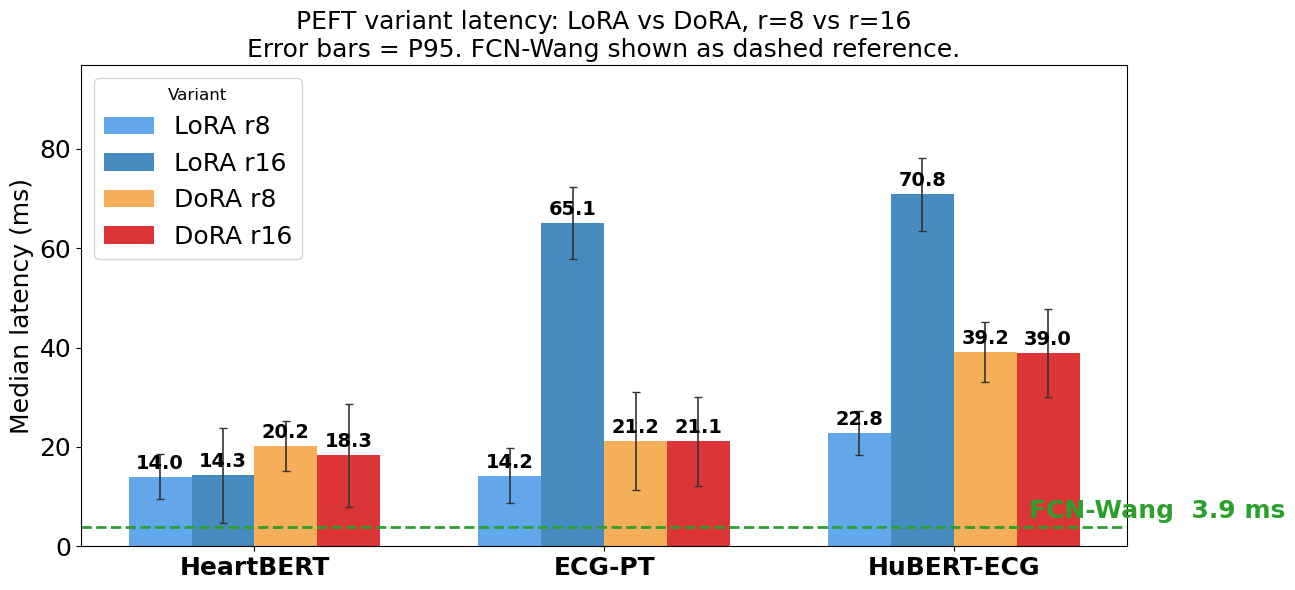

In [31]:
import matplotlib.patches as mpatches

variants = ['LoRA r8', 'LoRA r16', 'DoRA r8', 'DoRA r16']
colors   = ['#4C9BE8', '#2C7BB6', '#F4A442', '#D7191C']
models   = ['HeartBERT', 'ECG-PT', 'HuBERT-ECG']

medians = {
    'HeartBERT':  [hb_lora_r8_rep['latency_ms_median'],    hb_lora_r16_rep['latency_ms_median'],
                   hb_dora_r8_rep['latency_ms_median'],     hb_dora_r16_rep['latency_ms_median']],
    'ECG-PT':     [ecgpt_lora_r8_rep['latency_ms_median'],  ecgpt_lora_r16_rep['latency_ms_median'],
                   ecgpt_dora_r8_rep['latency_ms_median'],  ecgpt_dora_r16_rep['latency_ms_median']],
    'HuBERT-ECG': [hubert_lora_r8_rep['latency_ms_median'], hubert_lora_r16_rep['latency_ms_median'],
                   hubert_dora_r8_rep['latency_ms_median'], hubert_dora_r16_rep['latency_ms_median']],
}
p95s = {
    'HeartBERT':  [hb_lora_r8_rep['latency_ms_p95'],    hb_lora_r16_rep['latency_ms_p95'],
                   hb_dora_r8_rep['latency_ms_p95'],     hb_dora_r16_rep['latency_ms_p95']],
    'ECG-PT':     [ecgpt_lora_r8_rep['latency_ms_p95'],  ecgpt_lora_r16_rep['latency_ms_p95'],
                   ecgpt_dora_r8_rep['latency_ms_p95'],  ecgpt_dora_r16_rep['latency_ms_p95']],
    'HuBERT-ECG': [hubert_lora_r8_rep['latency_ms_p95'], hubert_lora_r16_rep['latency_ms_p95'],
                   hubert_dora_r8_rep['latency_ms_p95'], hubert_dora_r16_rep['latency_ms_p95']],
}

x       = np.arange(len(models))
width   = 0.18
offsets = np.linspace(-(len(variants) - 1) / 2, (len(variants) - 1) / 2, len(variants)) * width

fig, ax = plt.subplots(figsize=(13, 6))

for vi, (variant, color, offset) in enumerate(zip(variants, colors, offsets)):
    med_vals = [medians[m][vi] for m in models]
    p95_vals = [p95s[m][vi]    for m in models]
    errs     = [p - m for m, p in zip(med_vals, p95_vals)]
    bars = ax.bar(x + offset, med_vals, width, label=variant, color=color, alpha=0.88,
                  yerr=errs, error_kw=dict(elinewidth=1.2, capsize=3, ecolor='#333'))
    for bar, val in zip(bars, med_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f'{val:.1f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# FCN-Wang reference line
fcn_med = fcn_r['latency_ms_median']
ax.axhline(fcn_med, color='#2ca02c', lw=2.0, ls='--')
ax.text(len(models) - 0.05, fcn_med + 0.8, f'FCN-Wang  {fcn_med:.1f} ms',
        color='#2ca02c', ha='right', va='bottom', fontsize=18, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=18, fontweight='bold')
ax.set_ylabel('Median latency (ms)', fontsize=18)
ax.set_title('PEFT variant latency: LoRA vs DoRA, r=8 vs r=16\n'
             'Error bars = P95. FCN-Wang shown as dashed reference.',
             fontsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.legend(title='Variant', fontsize=18, title_fontsize=12, loc='upper left')
ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/latency_peft_comparison.png', dpi=150, bbox_inches='tight')
plt.show()